# **A Mixed-Methods Analysis of Repression and Mobilization in Bangladesh's July Revolution**

This notebook contains the full Exploratory Data Analysis (EDA) of the ACLED dataset during the July Revolution.

## **Importing Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import geopandas as gpd
from folium import Map, CircleMarker
from datetime import datetime
from textblob import TextBlob
import matplotlib.colors as mcolors
import matplotlib.dates as mdates

## **EDA on the Raw Dataset**

Summary of Fatalities:
count    856.000000
mean       0.671729
std        2.499767
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max       46.000000
Name: fatalities, dtype: float64
Event Type Distribution:
event_type
Riots                         442
Protests                      347
Violence against civilians     32
Strategic developments         24
Battles                        11
Name: count, dtype: int64


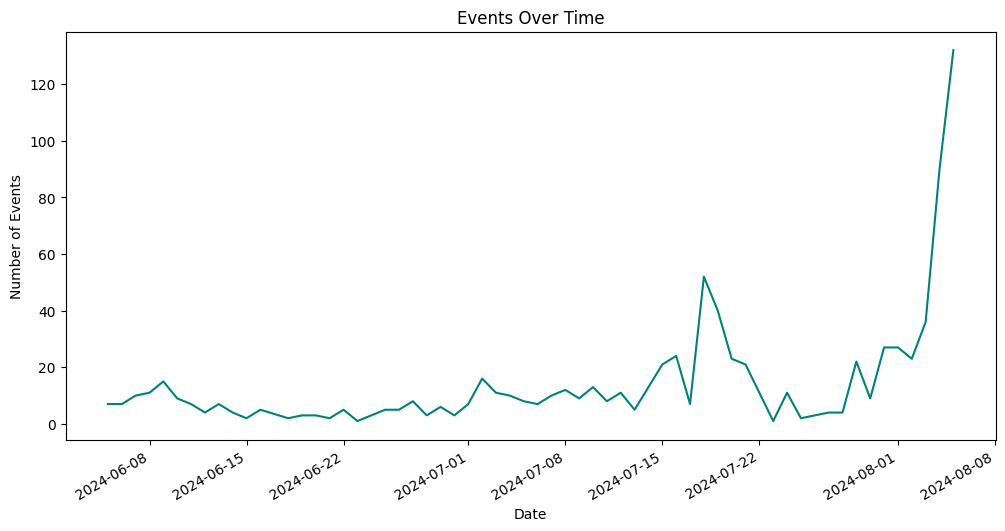

<ipython-input-4-818233d261c5>:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='event_type', y='fatalities', data=data, palette='viridis')


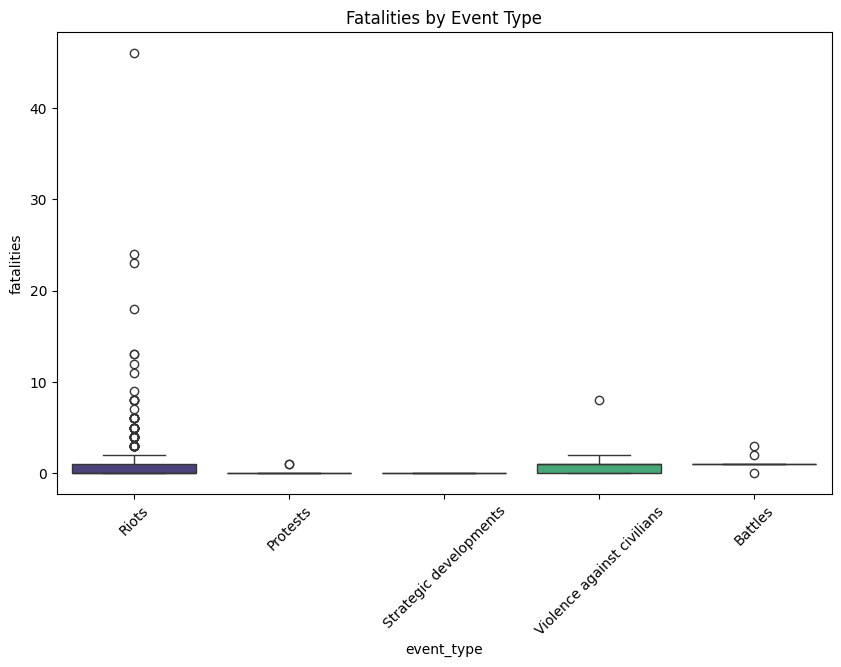

<Figure size 1200x800 with 0 Axes>

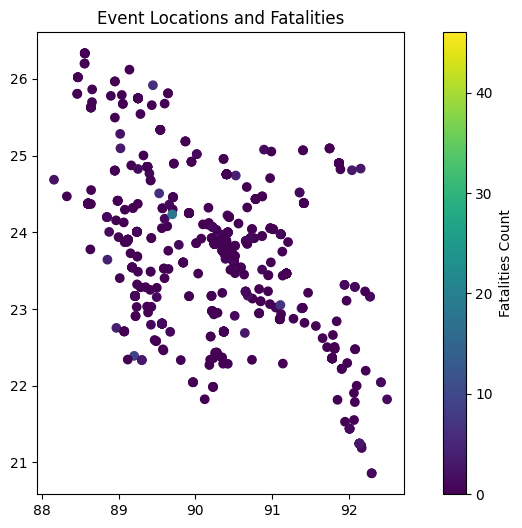

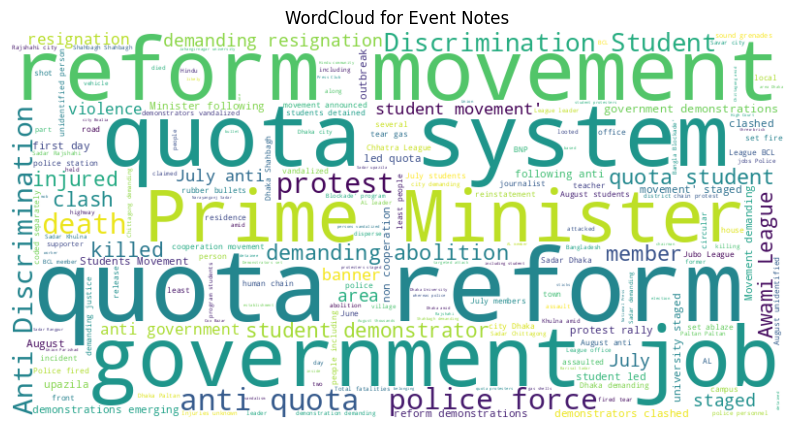

Cleaned data saved to /content/drive/MyDrive/Research/Bangladesh Movement Research/Cleaned_Bangladesh_Events.csv


In [ ]:
# Loading Raw Dataset
file_path = '/content/drive/MyDrive/Research/Bangladesh Movement Research/2024-06-05-2024-08-05-South_Asia-Bangladesh.csv'
data = pd.read_csv(file_path)

# 1. Data Cleaning
def clean_data(df):
    # Dropping duplicates
    df = df.drop_duplicates()

    # Filling missing values
    df['fatalities'] = df['fatalities'].fillna(0).astype(int)
    for col in ['actor2', 'assoc_actor_2', 'civilian_targeting']:
        df[col] = df[col].fillna('Unknown')

    # Converting dates
    df['event_date'] = pd.to_datetime(df['event_date'], errors='coerce')

    return df

data = clean_data(data)

# 2. Descriptive Statistics
print("Summary of Fatalities:")
print(data['fatalities'].describe())

print("Event Type Distribution:")
print(data['event_type'].value_counts())

# 3. Time Series Analysis
plt.figure(figsize=(12, 6))
data.groupby('event_date').size().plot(title='Events Over Time', color='teal')
plt.ylabel('Number of Events')
plt.xlabel('Date')
plt.show()

# 4. Fatality Analysis
plt.figure(figsize=(10, 6))
sns.boxplot(x='event_type', y='fatalities', data=data, palette='viridis')
plt.xticks(rotation=45)
plt.title('Fatalities by Event Type')
plt.show()

# 5. Geospatial Visualization
# Converting to GeoDataFrame
data['geometry'] = gpd.points_from_xy(data['longitude'], data['latitude'])
geodata = gpd.GeoDataFrame(data, geometry='geometry')

# Plotting on a map
plt.figure(figsize=(12, 8))
geodata.plot(column='fatalities', cmap='viridis', legend=True, figsize=(10, 6),
            legend_kwds={'label': "Fatalities Count"})
plt.title('Event Locations and Fatalities')
plt.show()

# 6. WordCloud for Notes
text = ' '.join(str(note) for note in data['notes'] if pd.notna(note))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud for Event Notes')
plt.show()

# 7. Interactive Map with Folium
m = Map(location=[23.685, 90.356], zoom_start=7)

for _, row in data.iterrows():
    CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=min(row['fatalities'] * 0.3 + 2, 10),  # Scale radius
        color='red',
        fill=True,
        fill_opacity=0.7,
        popup=f"Event: {row['event_type']}\nFatalities: {row['fatalities']}\nNotes: {row['notes']}"
    ).add_to(m)

m.save('/content/drive/MyDrive/Research/Bangladesh Movement Research/Bangladesh_Event_Map.html')

# Exporting cleaned data
cleaned_path = '/content/drive/MyDrive/Research/Bangladesh Movement Research/Cleaned_Bangladesh_Events.csv'
data.to_csv(cleaned_path, index=False)
print(f"Cleaned data saved to {cleaned_path}")


<ipython-input-3-50ea053cff90>:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['assoc_actor_1'].fillna('Unknown', inplace=True)
<ipython-input-3-50ea053cff90>:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

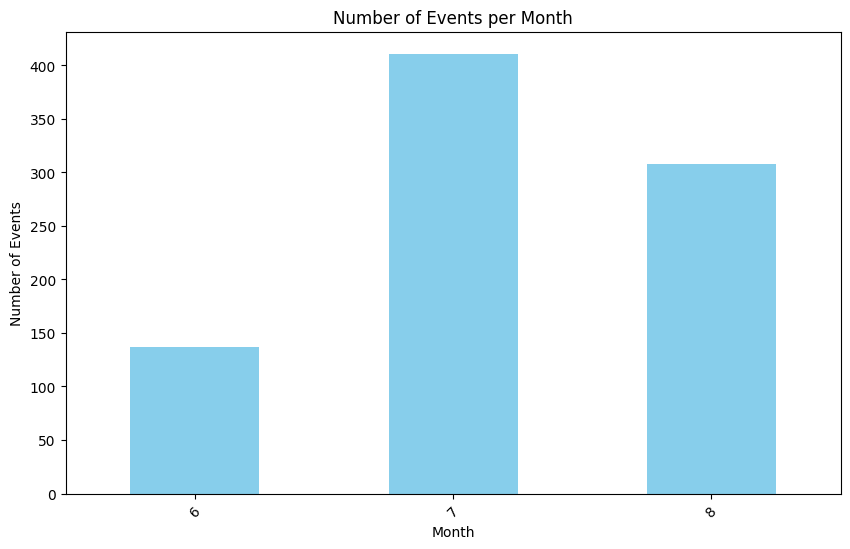

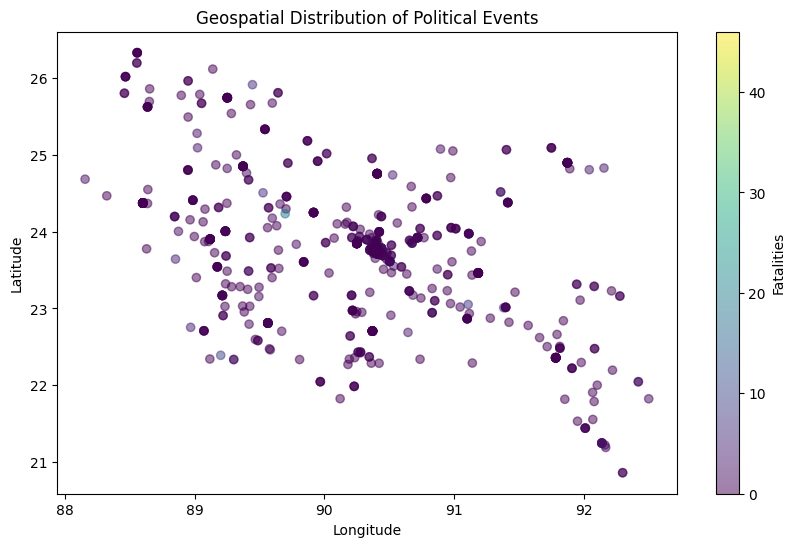

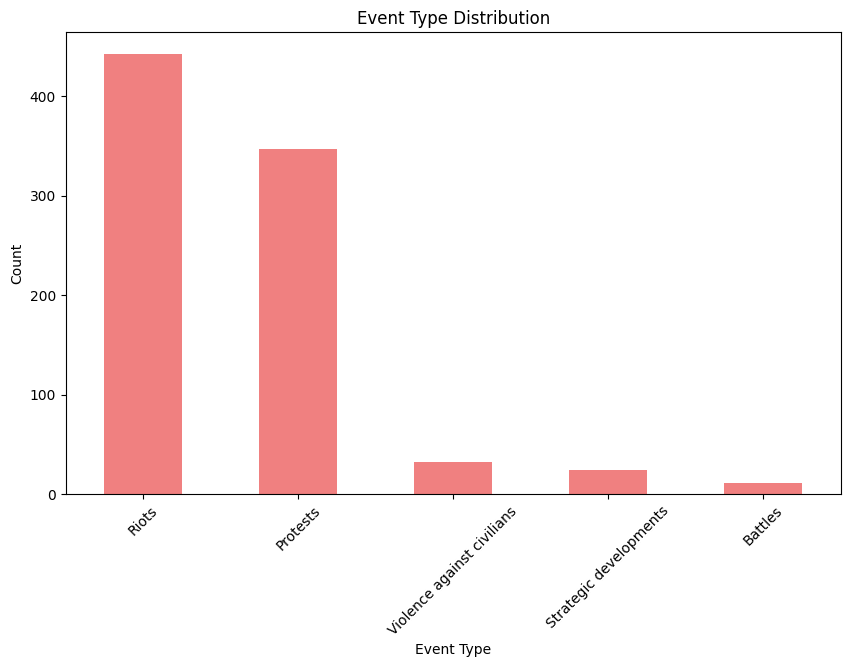

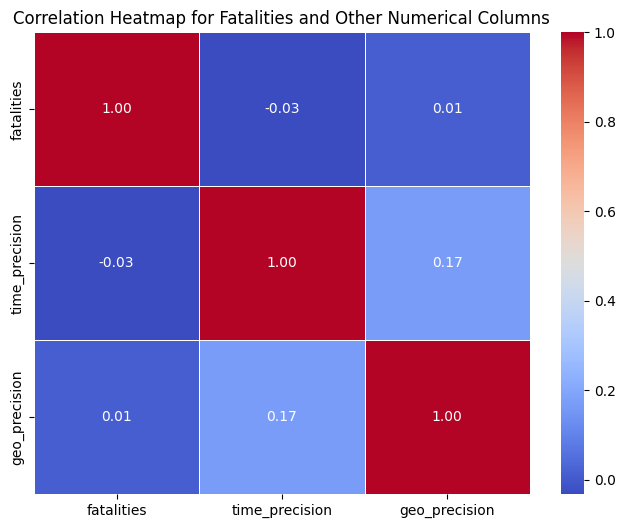

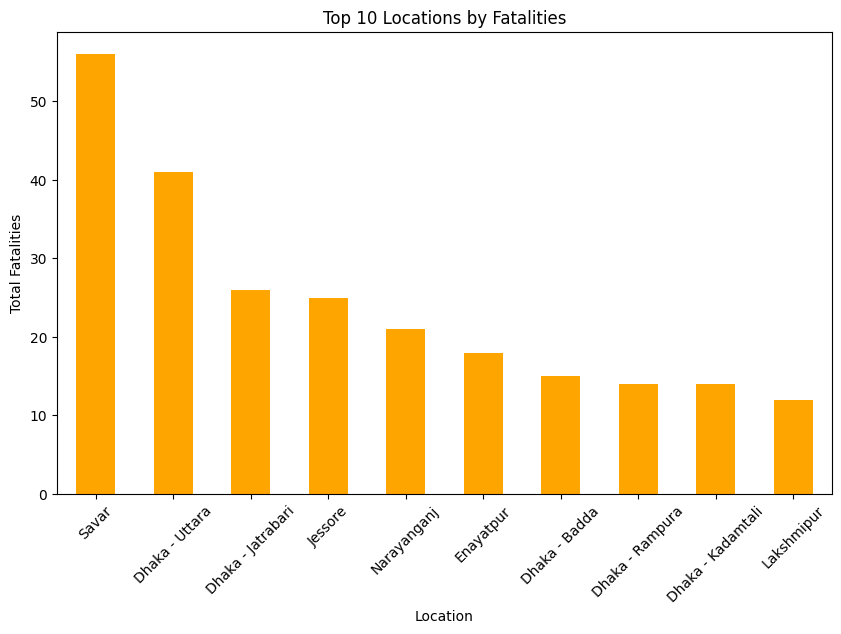

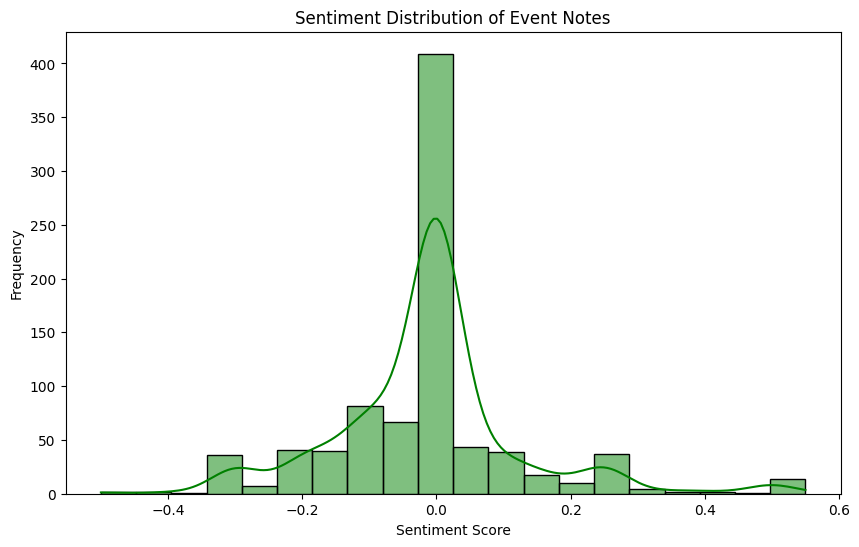

In [ ]:
# Loading Raw dataset
df = pd.read_csv('/content/drive/MyDrive/Research/Bangladesh Movement Research/2024-06-05-2024-08-05-South_Asia-Bangladesh.csv')

# 1. Data Cleaning
# Converting 'event_date' to datetime format
df['event_date'] = pd.to_datetime(df['event_date'], errors='coerce')

# Handling missing values
df['assoc_actor_1'].fillna('Unknown', inplace=True)
df['actor2'].fillna('Unknown', inplace=True)
df['fatalities'].fillna(0, inplace=True)

# 2. Further Exploratory Data Analysis (EDA)
# Event counts over time
df['month'] = df['event_date'].dt.month
monthly_events = df.groupby('month').size()

# Plotting the event counts by month
plt.figure(figsize=(10, 6))
monthly_events.plot(kind='bar', color='skyblue')
plt.title('Number of Events per Month')
plt.xlabel('Month')
plt.ylabel('Number of Events')
plt.xticks(rotation=45)
plt.show()

# 3. Geospatial Distribution of Events
# Plotting events on a map based on latitude and longitude
plt.figure(figsize=(10, 6))
plt.scatter(df['longitude'], df['latitude'], alpha=0.5, c=df['fatalities'], cmap='viridis')
plt.title('Geospatial Distribution of Political Events')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.colorbar(label='Fatalities')
plt.show()

# 4. Event Type Distribution
event_type_counts = df['event_type'].value_counts()

# Plotting event type distribution
plt.figure(figsize=(10, 6))
event_type_counts.plot(kind='bar', color='lightcoral')
plt.title('Event Type Distribution')
plt.xlabel('Event Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# 5. Fatalities Analysis
# Correlation between fatalities and other numerical columns
correlation = df[['fatalities', 'time_precision', 'geo_precision']].corr()

# Heatmap for correlation analysis
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap for Fatalities and Other Numerical Columns')
plt.show()

# 6. Top Locations with Fatalities
top_locations = df.groupby('location')['fatalities'].sum().sort_values(ascending=False).head(10)

# Plotting top locations by fatalities
plt.figure(figsize=(10, 6))
top_locations.plot(kind='bar', color='orange')
plt.title('Top 10 Locations by Fatalities')
plt.xlabel('Location')
plt.ylabel('Total Fatalities')
plt.xticks(rotation=45)
plt.show()

# 7. Sentiment Analysis (if text data is available in 'notes')

# Applying sentiment analysis on 'notes' column
df['sentiment'] = df['notes'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

# Plotting sentiment distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['sentiment'], bins=20, kde=True, color='green')
plt.title('Sentiment Distribution of Event Notes')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.show()


# **Visualization for Hypothesis 3 (Catalytic Moral Shock)**

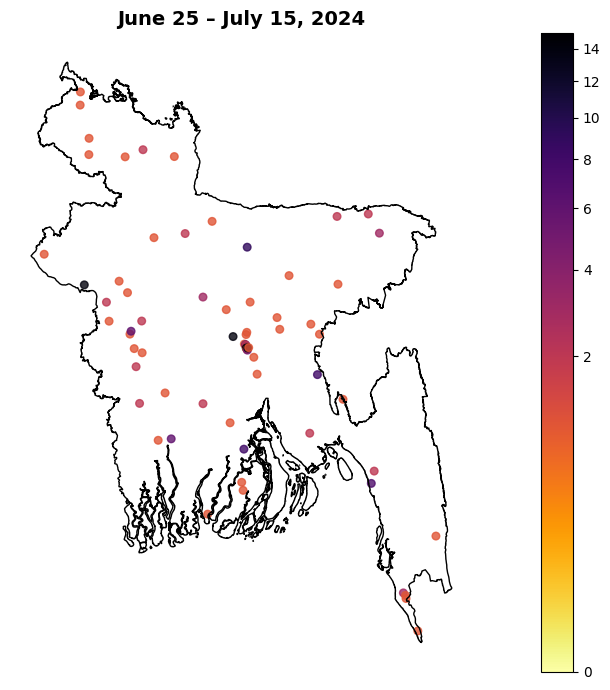

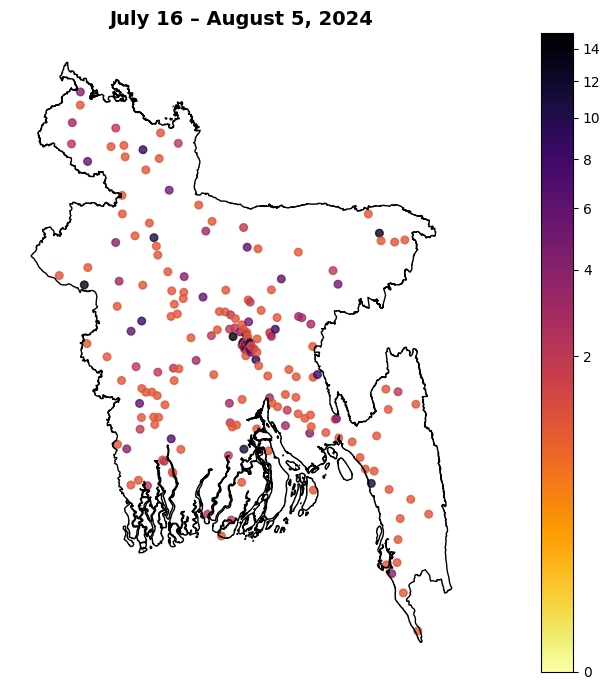

In [7]:
# -------------------------
# 1. Loading and Cleaning dataset
# -------------------------
df = pd.read_csv('/content/drive/MyDrive/Research/Bangladesh Movement Research/2024-06-05-2024-08-05-South_Asia-Bangladesh.csv')

df['event_date'] = pd.to_datetime(df['event_date'], errors='coerce')
df['assoc_actor_1'] = df['assoc_actor_1'].fillna('Unknown')
df['actor2'] = df['actor2'].fillna('Unknown')
df['fatalities'] = df['fatalities'].fillna(0)

# -------------------------
# 2. Splitting into Two periods
# -------------------------
period1 = df[(df['event_date'] >= '2024-06-25') & (df['event_date'] <= '2024-07-15')]
period2 = df[(df['event_date'] >= '2024-07-16') & (df['event_date'] <= '2024-08-05')]

# -------------------------
# 3. Loading high-resolution Bangladesh border (GADM Level 0)
# -------------------------
bangladesh = gpd.read_file('/content/drive/MyDrive/Research/Bangladesh Movement Research/gadm41_BGD_0.shp')

# -------------------------
# 4. Aggregate to event counts per coordinate
# -------------------------
def aggregate_events(df_period):
    counts = df_period.groupby(['longitude', 'latitude']).size().reset_index(name='event_count')
    return gpd.GeoDataFrame(counts, geometry=gpd.points_from_xy(counts.longitude, counts.latitude), crs="EPSG:4326")

gdf1 = aggregate_events(period1)
gdf2 = aggregate_events(period2)

# -------------------------
# 5. Shared PowerNorm color scale
# -------------------------
all_counts = pd.concat([gdf1['event_count'], gdf2['event_count']])
norm = mcolors.PowerNorm(gamma=0.35, vmin=0, vmax=15)
cmap = plt.cm.inferno_r

# -------------------------
# 6. Period 1 Plot
# -------------------------
fig, ax = plt.subplots(figsize=(14, 7))
bangladesh.boundary.plot(ax=ax, color='black', linewidth=1)
gdf1.plot(ax=ax, column='event_count', cmap=cmap, markersize=30, alpha=0.8, legend=True, norm=norm)
ax.set_title('June 25 – July 15, 2024', fontsize=14, weight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.show()

# -------------------------
# 7. Period 2 Plot
# -------------------------
fig, ax = plt.subplots(figsize=(14, 7))
bangladesh.boundary.plot(ax=ax, color='black', linewidth=1)
gdf2.plot(ax=ax, column='event_count', cmap=cmap, markersize=30, alpha=0.8, legend=True, norm=norm)
ax.set_title('July 16 – August 5, 2024', fontsize=14, weight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.show()


# **Visualization of Day-wise Protest Events and Fatalities (Using Modified Dataset)**

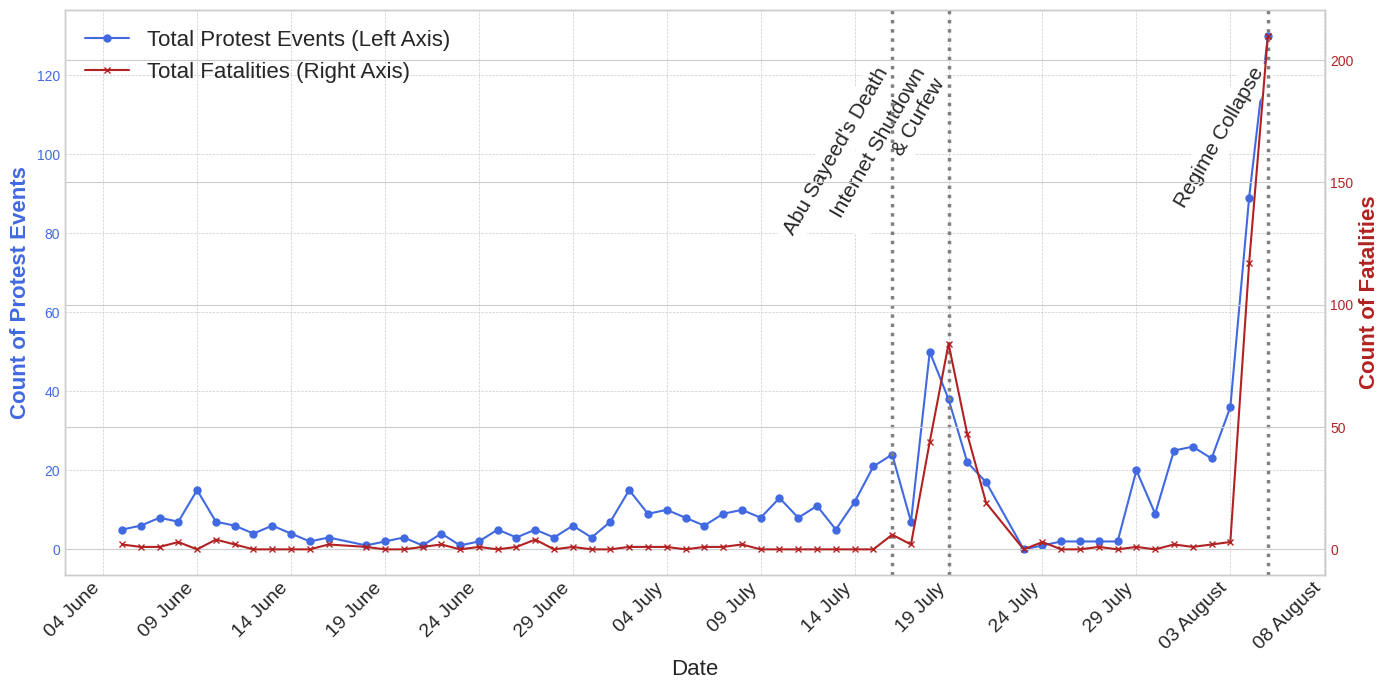

In [ ]:
# --- 1. Loading & Preparing Data ---
file_path = '/content/drive/MyDrive/Research/Bangladesh Movement Research/daily_event_summary_with_new_columns.csv'
data = pd.read_csv(file_path)
data['event_date'] = pd.to_datetime(data['event_date'])
data = data.sort_values('event_date').reset_index(drop=True)
if 'Protests' in data.columns and 'Riots' in data.columns:
    data['mobilization_events'] = data['Protests'] + data['Riots']
else:
    data['mobilization_events'] = data['total_events']

# --- 2. Creating a Professional Plot ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax1 = plt.subplots(figsize=(14,7))

# This command explicitly draws the grid and sets its z-order to 0 (the bottom layer).
# All other plot elements will now be drawn on top of it by default.
ax1.grid(True, which='both', linestyle='--', linewidth=0.5, zorder=0)

# --- Plotting Total Events on the primary (left) Y-axis ---
color1 = 'royalblue'
ax1.set_xlabel('Date', fontsize=16)
ax1.set_ylabel('Count of Protest Events', color=color1, fontsize=16, weight='bold')
ax1.plot(data['event_date'], data['mobilization_events'], color=color1, linestyle='-', marker='o', markersize=5, label='Total Protest Events (Left Axis)')
ax1.tick_params(axis='y', labelcolor=color1)

# --- Creating a second Y-axis for Total Fatalities ---
ax2 = ax1.twinx()
color2 = 'firebrick'
ax2.set_ylabel('Count of Fatalities', color=color2, fontsize=16, weight='bold')
ax2.plot(data['event_date'], data['total_fatalities'], color=color2, linestyle='-', marker='x', markersize=5, label='Total Fatalities (Right Axis)')
ax2.tick_params(axis='y', labelcolor=color2)

# --- 3. Formatting & Annotations ---
#plt.title('Daily Protest Events and Fatalities During the July Revolution', fontsize=16, weight='bold')
date_format = mdates.DateFormatter('%d %B')
ax1.xaxis.set_major_formatter(date_format)
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=5))
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right", fontsize=14)

key_dates = {
    '2024-07-16': "Abu Sayeed's Death",
    '2024-07-19': "Internet Shutdown\n& Curfew",
    '2024-08-05': "Regime Collapse"
}
y_lim_top = ax1.get_ylim()[1]
for date_str, label in key_dates.items():
    date = pd.to_datetime(date_str)
    ax1.axvline(x=date, color='gray', linestyle=':', linewidth=2.5, zorder=100)
    ax1.text(date, y_lim_top * 0.9, label, rotation=60, verticalalignment='top',
             horizontalalignment='right', fontsize=15, backgroundcolor='w')

# --- Creating a single, combined legend with a solid background ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
legend = ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=16)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(1.0)
legend.set_zorder(100)

# Final adjustments and display
plt.tight_layout()
plt.show()